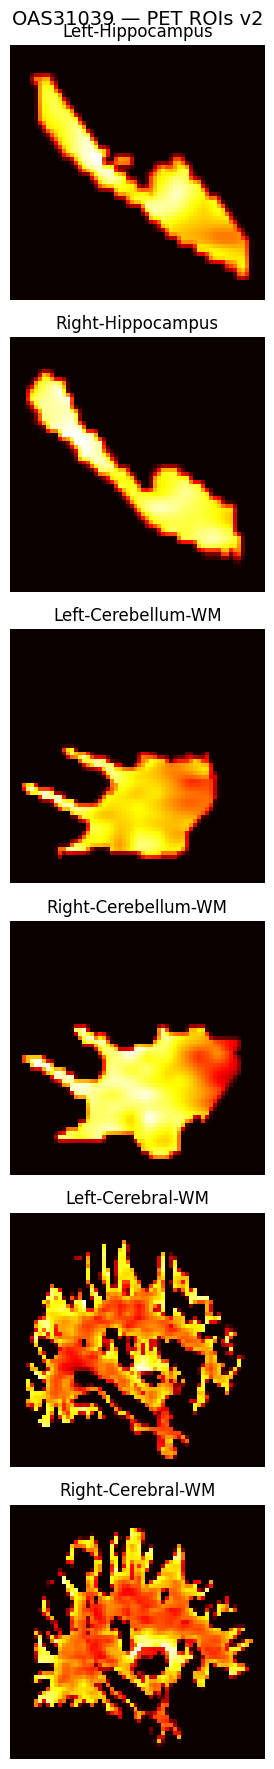

In [2]:
import pandas as pd
import nibabel as nib
import numpy as np
from scipy.ndimage import zoom
import matplotlib.pyplot as plt

df = pd.read_csv('D:/mamba_model/thesis_cohort_final.csv')

FS_OUTPUT = 'E:/Oasis3/FastSurfer_output'
PET_REG_V2 = 'E:/Oasis3/PET_registered_v2'

ROI_INFO = {
    'Left-Hippocampus':    17,
    'Right-Hippocampus':   53,
    'Left-Cerebellum-WM':   7,
    'Right-Cerebellum-WM': 46,
    'Left-Cerebral-WM':     2,
    'Right-Cerebral-WM':   41,
}
ROI_SIZE = (64, 64, 64)

subj = df.iloc[1]  # OAS31039
seg_data = nib.load(f"{FS_OUTPUT}/{subj['mri_session']}/mri/aparc.DKTatlas+aseg.deep.mgz").get_fdata()
pet_data = nib.load(f"{PET_REG_V2}/{subj['subject_id']}_PIB_in_MRI.nii.gz").get_fdata()

fig, axes = plt.subplots(6, 1, figsize=(5, 18))
fig.suptitle(f"{subj['subject_id']} — PET ROIs v2", fontsize=14)

for i, (roi_name, label_id) in enumerate(ROI_INFO.items()):
    mask = (seg_data == label_id)
    roi_vol = pet_data * mask
    coords = np.where(mask)
    
    pad = 3
    z1 = max(0, coords[0].min() - pad)
    z2 = min(seg_data.shape[0]-1, coords[0].max() + pad)
    y1 = max(0, coords[1].min() - pad)
    y2 = min(seg_data.shape[1]-1, coords[1].max() + pad)
    x1 = max(0, coords[2].min() - pad)
    x2 = min(seg_data.shape[2]-1, coords[2].max() + pad)
    
    cropped = roi_vol[z1:z2+1, y1:y2+1, x1:x2+1]
    zoom_factors = [t/s for t, s in zip(ROI_SIZE, cropped.shape)]
    resized = zoom(cropped, zoom_factors, order=1)
    
    axes[i].imshow(resized[32, :, :], cmap='hot')
    axes[i].set_title(roi_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

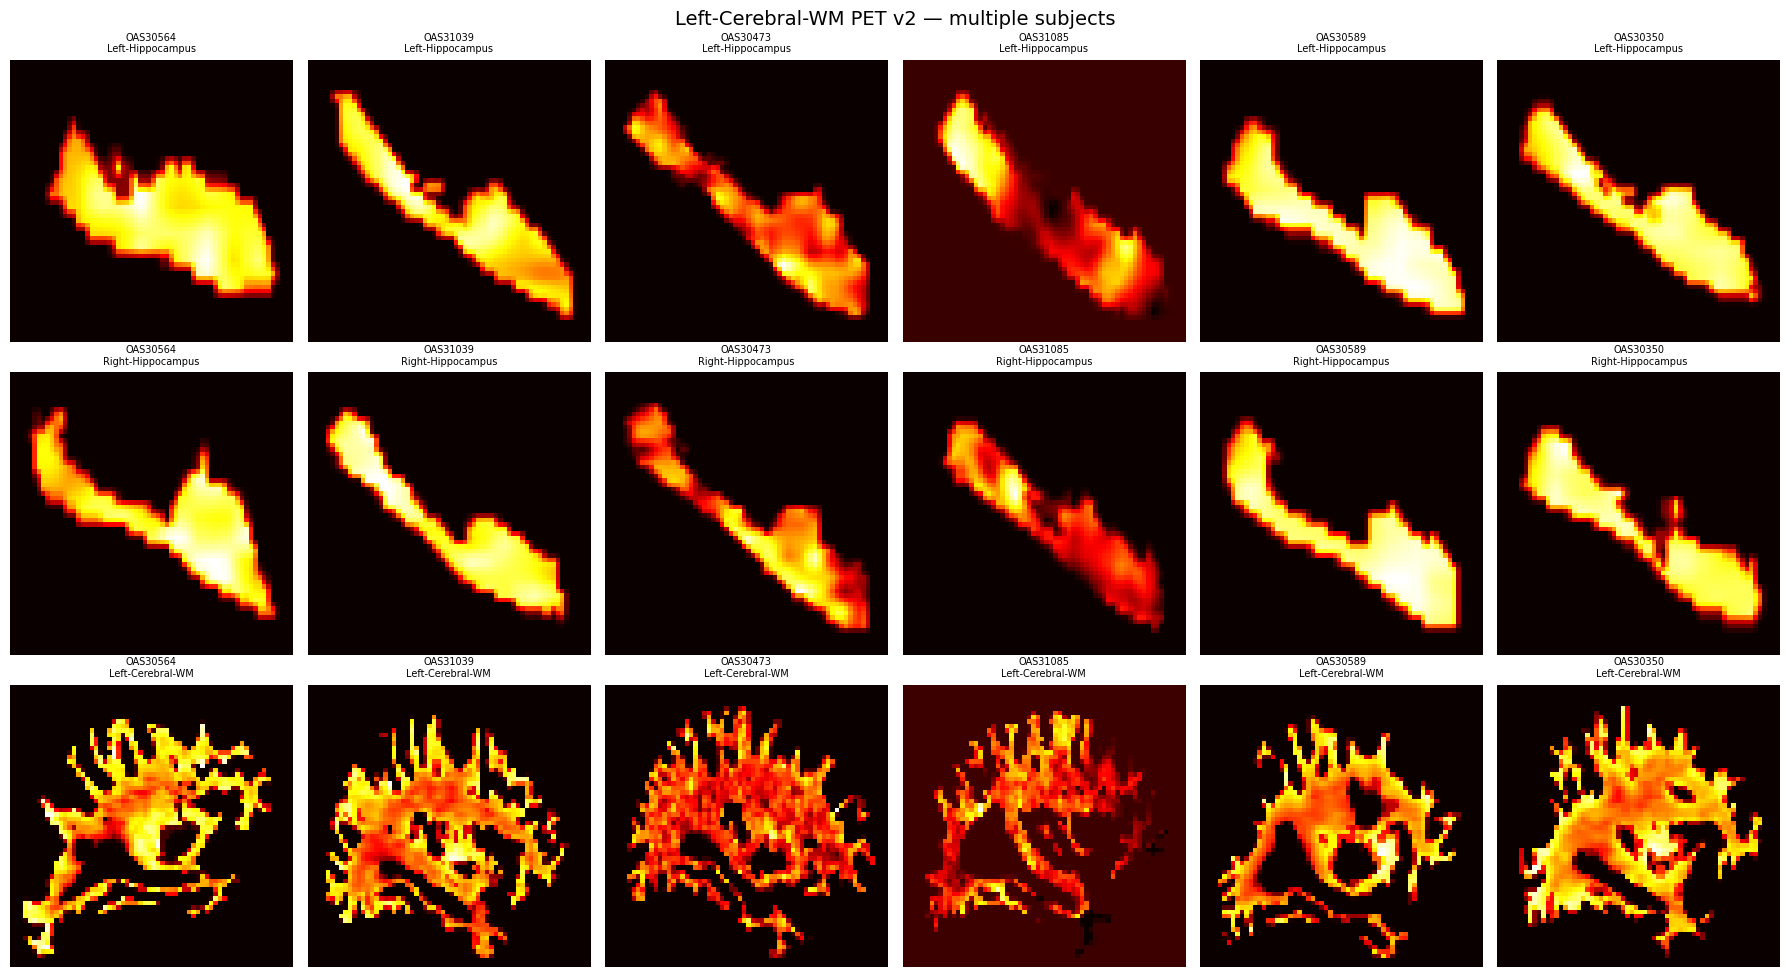

In [3]:
fig, axes = plt.subplots(3, 6, figsize=(18, 10))
fig.suptitle('Left-Cerebral-WM PET v2 — multiple subjects', fontsize=14)

for col, idx in enumerate([0, 1, 2, 5, 10, 15]):
    subj = df.iloc[idx]
    pet_path = f"{PET_REG_V2}/{subj['subject_id']}_PIB_in_MRI.nii.gz"
    
    import os
    if not os.path.exists(pet_path):
        axes[0, col].set_title(f"{subj['subject_id']}\nNot done yet")
        continue
    
    seg = nib.load(f"{FS_OUTPUT}/{subj['mri_session']}/mri/aparc.DKTatlas+aseg.deep.mgz").get_fdata()
    pet = nib.load(pet_path).get_fdata()
    
    for row, (roi_name, label_id) in enumerate([(k,v) for k,v in ROI_INFO.items() if 'Cerebral' in k or 'Hippocampus' in k][:3]):
        mask = (seg == label_id)
        roi_vol = pet * mask
        coords = np.where(mask)
        pad = 3
        z1 = max(0, coords[0].min()-pad); z2 = min(seg.shape[0]-1, coords[0].max()+pad)
        y1 = max(0, coords[1].min()-pad); y2 = min(seg.shape[1]-1, coords[1].max()+pad)
        x1 = max(0, coords[2].min()-pad); x2 = min(seg.shape[2]-1, coords[2].max()+pad)
        cropped = roi_vol[z1:z2+1, y1:y2+1, x1:x2+1]
        zoom_factors = [t/s for t, s in zip(ROI_SIZE, cropped.shape)]
        resized = zoom(cropped, zoom_factors, order=1)
        axes[row, col].imshow(resized[32, :, :], cmap='hot')
        axes[row, col].set_title(f"{subj['subject_id']}\n{roi_name}", fontsize=7)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

MRI cache: 210/210
PET cache: 210/210
MRI shape: (6, 64, 64, 64)
PET shape: (6, 64, 64, 64)


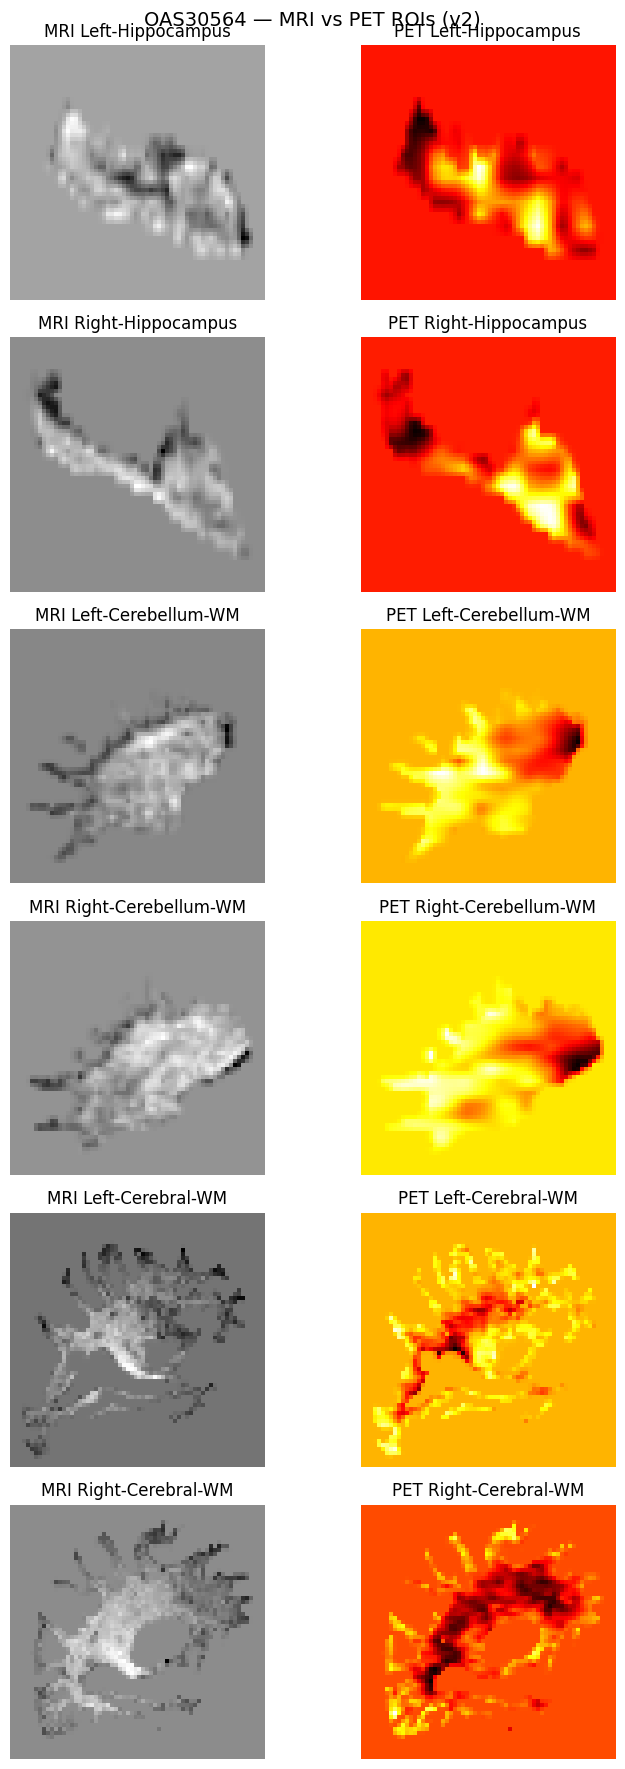

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from scipy.ndimage import zoom
import os

df = pd.read_csv('D:/mamba_model/thesis_cohort_final.csv')
mri_cache = 'D:/mamba_model/preprocessed_cache_roi64'
pet_cache = 'D:/mamba_model/preprocessed_cache_pet'

ROI_NAMES = [
    'Left-Hippocampus', 'Right-Hippocampus',
    'Left-Cerebellum-WM', 'Right-Cerebellum-WM',
    'Left-Cerebral-WM', 'Right-Cerebral-WM'
]

# Cache check
mri_ok = sum(os.path.exists(f"{mri_cache}/{row['mri_session']}.npy") for _, row in df.iterrows())
pet_ok = sum(os.path.exists(f"{pet_cache}/{row['subject_id']}_PIB.npy") for _, row in df.iterrows())
print(f'MRI cache: {mri_ok}/210')
print(f'PET cache: {pet_ok}/210')

# Shape check
mri = np.load(f"{mri_cache}/{df.iloc[0]['mri_session']}.npy")
pet = np.load(f"{pet_cache}/{df.iloc[0]['subject_id']}_PIB.npy")
print(f'MRI shape: {mri.shape}')
print(f'PET shape: {pet.shape}')

# Visual check
fig, axes = plt.subplots(6, 2, figsize=(8, 18))
fig.suptitle(f"{df.iloc[0]['subject_id']} — MRI vs PET ROIs (v2)", fontsize=14)

for i, roi_name in enumerate(ROI_NAMES):
    axes[i, 0].imshow(mri[i, 32, :, :], cmap='gray')
    axes[i, 0].set_title(f'MRI {roi_name}')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(pet[i, 32, :, :], cmap='hot')
    axes[i, 1].set_title(f'PET {roi_name}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ── Quick dataset ─────────────────────────────────────────────
class MultimodalDataset(Dataset):
    def __init__(self, sessions, subject_ids, labels):
        self.sessions = sessions
        self.subject_ids = subject_ids
        self.labels = labels

    def __len__(self):
        return len(self.sessions)

    def __getitem__(self, idx):
        mri = np.load(f"D:/mamba_model/preprocessed_cache_roi64/{self.sessions[idx]}.npy")
        pet = np.load(f"D:/mamba_model/preprocessed_cache_pet/{self.subject_ids[idx]}_PIB.npy")
        label = self.labels[idx]
        return (torch.tensor(mri, dtype=torch.float32),
                torch.tensor(pet, dtype=torch.float32),
                torch.tensor(label, dtype=torch.long))

# ── Minimal multimodal model ──────────────────────────────────
class QuickMultimodal(nn.Module):
    def __init__(self):
        super().__init__()
        self.mri_encoder = nn.Sequential(
            nn.Conv3d(6, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(4),
            nn.Flatten()
        )
        self.pet_encoder = nn.Sequential(
            nn.Conv3d(6, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(4),
            nn.Flatten()
        )
        self.classifier = nn.Linear(8*4*4*4*2, 2)

    def forward(self, mri, pet):
        mri_feat = self.mri_encoder(mri)
        pet_feat = self.pet_encoder(pet)
        combined = torch.cat([mri_feat, pet_feat], dim=1)
        return self.classifier(combined)

# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv('D:/mamba_model/thesis_cohort_final.csv')
sessions = df['mri_session'].values
subject_ids = df['subject_id'].values
labels = df['outcome_label'].values

X_idx = np.arange(len(df))
X_train, X_test = train_test_split(X_idx, test_size=0.2, random_state=42, stratify=labels)

train_ds = MultimodalDataset(sessions[X_train], subject_ids[X_train], labels[X_train])
test_ds  = MultimodalDataset(sessions[X_test],  subject_ids[X_test],  labels[X_test])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=0)

# ── Quick training test ───────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = QuickMultimodal().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# One epoch
model.train()
total_loss = 0
correct = 0
total = 0

for mri, pet, label in train_loader:
    mri, pet, label = mri.to(device), pet.to(device), label.to(device)
    optimizer.zero_grad()
    out = model(mri, pet)
    loss = criterion(out, label)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    correct += (out.argmax(1) == label).sum().item()
    total += len(label)

print(f'Train Loss: {total_loss/len(train_loader):.4f}')
print(f'Train Acc: {correct/total*100:.1f}%')

# Test pass
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for mri, pet, label in test_loader:
        mri, pet, label = mri.to(device), pet.to(device), label.to(device)
        out = model(mri, pet)
        correct += (out.argmax(1) == label).sum().item()
        total += len(label)

print(f'Test Acc: {correct/total*100:.1f}%')
print('Multimodal pipeline working!')

Device: cuda
Train Loss: 1.2736
Train Acc: 46.4%
Test Acc: 50.0%
Multimodal pipeline working!
